**MSE on California Housing Data**

Predict the median house value. Since house values are continuous, we measure the "distance" between the predicted price and the actual price using MSE.

The Mathematical FormulaThe formula is defined as:$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$ Context

$n$Number of samplesThe total number of data points in your X_test set.

$\sum$SummationAdding up the errors for every individual prediction.

$y_i$Actual ValueThe "Ground Truth" (e.g., the true house price or true network latency).

$\hat{y}_i$Predicted ValueThe value generated by your model (e.g., reg_model.predict).

$(y_i - \hat{y}_i)$Error (Residual)The distance between the actual point and your model's prediction.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


X: We convert the raw NumPy array into a Pandas DataFrame to keep the feature names (e.g., MedInc, HouseAge).

y (The Target): In this specific dataset, the values are represented in units of 100,000. So, a y value of 4.5 means $450,000.

In [ ]:
# Load Housing Data
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target # Target is in units of 100k

test_size=0.2: You are using 16,512 houses to train the model and saving 4,128 houses for the final exam.

random_state=42: Ensures that every time you run this, the same houses go into the training set, maintaining scientific reproducibility.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The Math: The model calculates weights ($w$) for each feature (e.g., how much does an extra bedroom add to the price?). It solves the equation:$$y = w_1x_1 + w_2x_2 + ... + w_nx_n + b$$

In [ ]:
# Train Linear Regression
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)


LinearRegression()

predict: The model looks at the features of the 4,128 test houses and guesses their prices.

mse_val: Calculates the average of the squared differences between the actual and predicted prices. Because it's "squared," it heavily penalizes large errors.

In [ ]:
# Predict and Calculate MSE
y_pred = reg_model.predict(X_test)
mse_val = mean_squared_error(y_test, y_pred)

RMSE (Root Mean Squared Error): Since MSE is in "squared units," we take the square root to bring the error back to the original scale ($100k units).

Practical Meaning: If your RMSE is 0.70, your model is, on average, missing the actual house price by approximately $70,000.

In [ ]:
print(f"Regression MSE: {mse_val:.4f}")
print(f"Root MSE (RMSE): {np.sqrt(mse_val):.4f} (Avg error is approx ${np.sqrt(mse_val)*100:.2f}k)")

Regression MSE: 0.5559
Root MSE (RMSE): 0.7456 (Avg error is approx $74.56k)


**Binary Cross-Entropy on Cancer Data**


Classify tumors as Malignant or Benign. Because this is a probability-based task (0 to 1), using MSE is mathematically inefficient (it creates a "non-convex" surface that's hard to optimize). Instead, we use Log Loss.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score

load_breast_cancer(): Loads a diagnostic dataset containing 569 samples.

cancer.data ($X_c$): Contains 30 features like "mean radius," "texture," and "perimeter" of cell nuclei.

cancer.target ($y_c$): The binary labels where 0 usually represents malignant and 1 represents benign.

In [ ]:
# Load Cancer Data
cancer = load_breast_cancer()
X_c, y_c = cancer.data, cancer.target

test_size=0.2: You reserve 20% of the data (114 samples) to test the model's performance on patients it hasn't "seen" during training.

random_state=42: As we have discussed in your previous IoMT research labs, this ensures the split is the same every time you run the code, allowing for reproducible results

In [ ]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

LogisticRegression: Despite the name, this is a classifier. It uses the Sigmoid function to map any real-valued number into a range between 0 and 1.

max_iter=10000: High-dimensional data (like these 30 features) can take many iterations to find the optimal boundary. This prevents "failure to converge" errors.

In [ ]:

# Train Logistic Regression
log_model = LogisticRegression(max_iter=10000)
log_model.fit(X_train_c, y_train_c)

LogisticRegression(max_iter=10000)

 Instead of just giving a "Yes/No" answer, predict_proba returns the raw confidence levels.

 The Structure: It returns an array with two columns: $[Prob(0), Prob(1)]$. For medical AI, knowing a model is 99% sure vs. 51% sure is critical for clinical decision-making.

In [ ]:
# Get Probabilities (needed for Log Loss)
y_prob = log_model.predict_proba(X_test_c)

log_loss: This measures "uncertainty." If the model is confidently wrong (predicts 0.9 probability for the wrong class), Log Loss penalizes it heavily. In your PhD work, lower Log Loss is the goal.

accuracy_score: The simple percentage of correct diagnoses.

In [ ]:
# Calculate Metrics
loss = log_loss(y_test_c, y_prob)
acc = accuracy_score(y_test_c, log_model.predict(X_test_c))


Displays the final error rate. Because medical datasets are high-stakes, you are using 4 decimal places to capture even subtle improvements in model performance.

In [ ]:
print(f"Classification Log Loss: {loss:.4f}")
print(f"Classification Accuracy: {acc*100:.2f}%")

Classification Log Loss: 0.0799
Classification Accuracy: 95.61%


In this section, we will generate data, calculate** $R^2$** manually to understand the ratio, and then use scikit-learn.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [ ]:
# 1. Load Dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target

In [ ]:
# We'll use 'MedInc' (Median Income) as our primary predictor
X = df[['MedInc']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# 2. Train Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
# 3. Predict
y_pred = model.predict(X_test)

 The Mathematical IntuitionTo understand $R^2$, you have to compare two things:Your Model: The line/curve your algorithm created.The Baseline: A simple horizontal line representing the mean (average) of all $y$ values.The formula is expressed as:$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$$


 $SS_{res}$ (Residual Sum of Squares): The sum of the squares of the errors (the distance between your model and the actual data).

 $SS_{tot}$ (Total Sum of Squares): The sum of the squares of the distance between the actual data and the mean line.2.

 Interpreting the Values$R^2$ usually ranges from 0 to 1, and it is often expressed as a percentage:

 $R^2 = 0$: Your model is no better than simply guessing the average value for every input. It explains $0\%$ of the variability.

 $R^2 = 1$: Your model is perfect. Every single data point falls exactly on your regression line. It explains $100\%$ of the variability.

 $R^2 < 0$: This is rare but possible. It means your model is actually worse than just guessing the average. This usually happens when you force a model to follow a trend that isn't there.

  r2_score(y_test, y_pred) R-squared ($R^2$) score, or the Coefficient of Determination, measures the proportion of variance in the dependent variable that is predictable from the independent variables.

In [ ]:
# 4. Calculate Scores
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"R-squared Score: {r2:.4f}")
print(f"Mean Squared Error: {mse:.4f}")

R-squared Score: 0.4589
Mean Squared Error: 0.7091


X_test, y_test: This plots the ground truth points from your test set (the data the model was evaluated on).

color='gray': Using a neutral color like gray is a professional choice; it ensures the data points don't "compete" visually with your model's prediction line.

alpha=0.5: This makes the points semi-transparent. This is crucial for large datasets (like California Housing) because it reveals density. If many points overlap, they will appear darker, showing you where the "center of gravity" of your data lies.

label='Actual Data': This registers the data in the plot’s legend.

plt.axhline: This command draws a permanent horizontal line across the entire width of the plot.

y_test.mean(): This is the y-coordinate of the line. It represents the average value of all target labels.

The Logic: In statistics, the mean is considered the "simplest possible model." If you knew nothing about a house except its location in California, your best "blind guess" for its price would be the average price of all houses in California.

linestyle='--': Using a dashed line signifies that this is a reference boundary rather than a predicted model line.

color='blue': A standard color for a baseline to distinguish it from the "actual" data and the "model" prediction.


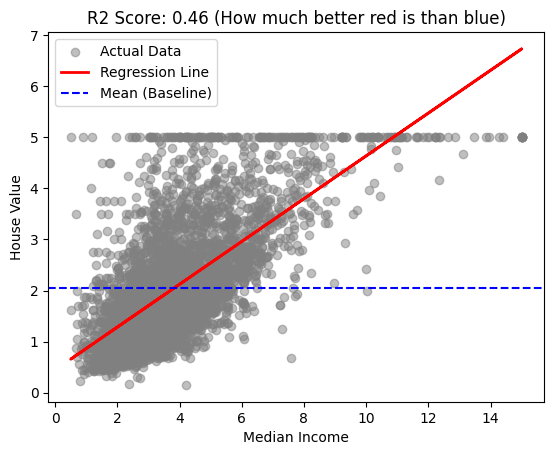

In [ ]:
# 5. Visualize the Fit
plt.scatter(X_test, y_test, color='gray', alpha=0.5, label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.axhline(y_test.mean(), color='blue', linestyle='--', label='Mean (Baseline)')
plt.xlabel('Median Income')
plt.ylabel('House Value')
plt.title(f'R2 Score: {r2:.2f} (How much better red is than blue)')
plt.legend()
plt.show()

**Confusion Matrix**
Key Components:

True Positive (TP): Predicted Sick, Actually Sick.

True Negative (TN): Predicted Healthy, Actually Healthy.

False Positive (FP): Predicted Sick, Actually Healthy (Type I Error).

False Negative (FN): Predicted Healthy, Actually Sick (Type II Error).

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
# 1. Load Dataset
data = load_breast_cancer()
X = data.data
y = data.target # 0: Malignant, 1: Benign

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
# 2. Train Logistic Regression
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [ ]:
# 3. Predict
y_pred = model.predict(X_test)

In [ ]:
# 4. Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

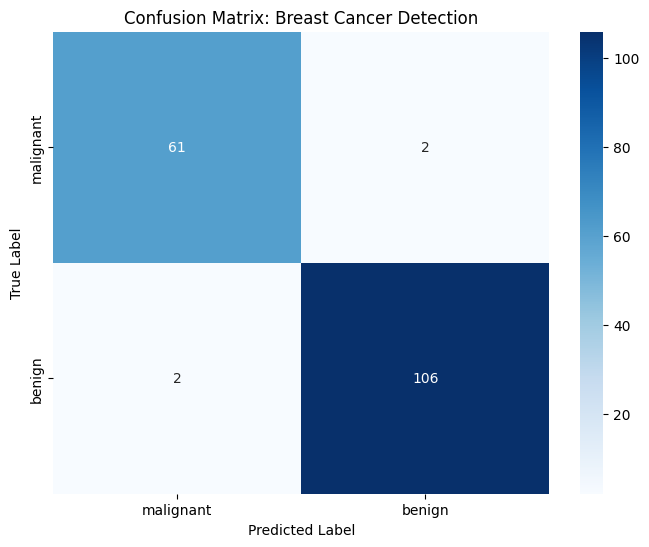

In [ ]:
# 5. Visualize with Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Breast Cancer Detection')
plt.show()

In [ ]:
# 6. Detailed Metrics
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       0.97      0.97      0.97        63
      benign       0.98      0.98      0.98       108

    accuracy                           0.98       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



Accuracy in Classification (Logistic Regression)In classification, accuracy is straightforward:$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}}$$

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
# 1. Load Data (Iris dataset: 3 classes of flowers)
data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

In [ ]:
# 2. Train Model
clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [ ]:
# 3. Predict and Calculate Accuracy
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Classification Accuracy: {acc * 100:.2f}%")

Classification Accuracy: 100.00%


**Accuracy in Regression (Linear Regression)**
In Regression, we don't usually use the word "Accuracy" because a prediction of $499,999  for a  $500,000 house is technically "incorrect" but practically perfect. Instead, we use Explained Variance or Tolerance-based Accuracy.

In [ ]:
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression

In [ ]:
from sklearn.model_selection import train_test_split
# 1. Load Data
housing = fetch_california_housing()
X_h, y_h = housing.data, housing.target
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

In [ ]:
# 2. Train Model
reg = LinearRegression()
reg.fit(X_train_h, y_train_h)

LinearRegression()

within_tolerance = np.abs((y_test_h - y_pred_h) / y_test_h) <= 0.10
This is the most critical line. It calculates the Mean Absolute Percentage Error (MAPE) logic for each individual prediction:

(y_test_h - y_pred_h): Calculates the raw error (how much we missed by).

/ y_test_h: Normalizes that error against the actual value. For example, a $10k  error  on  a $100k house is a 10%  error, but a $10k  error  on  a $1M house is only 1%.

np.abs(...): Ensures that being $10k "over"

 is treated the same as being $10k "under."

<= 0.10: This creates a Boolean Mask (a list of True/False values). If the relative error is 10% or less, it marks it as True (a success).

In [ ]:
# 3. Custom "Accuracy": Within 10% of the true value
y_pred_h = reg.predict(X_test_h)
within_tolerance = np.abs((y_test_h - y_pred_h) / y_test_h) <= 0.10
regression_accuracy = np.mean(within_tolerance)

print(f"Regression 'Accuracy' (within 10% error): {regression_accuracy * 100:.2f}%")

Regression 'Accuracy' (within 10% error): 23.64%


**Precision & Recall (Classification)**
In Logistic Regression, we are often making a high-stakes choice.

Precision: "Of all the times the model predicted 'Positive', how often was it right?"

Recall: "Of all the actual 'Positive' cases, how many did the model catch?"

In [ ]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score

In [ ]:
# 1. Load Data (Malignant vs Benign)
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)

In [ ]:
# 2. Train Model
# Note: 1 is 'Benign', 0 is 'Malignant'. In medical labs, we usually focus on the positive class.
clf = LogisticRegression(max_iter=10000)
clf.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [ ]:
# 3. Predict
y_pred = clf.predict(X_test)

Precision
Precision answers: "Of all instances the model predicted as Positive, how many were actually Positive?"Formula:$$Precision = \frac{TP}{TP + FP}$$

Recall Recall (also called Sensitivity) answers: "Of all actual Positive instances that exist, how many did the model manage to find?"Formula:$$Recall = \frac{TP}{TP + FN}$$

F1-Score (The Balance)The F1-Score is the harmonic mean of Precision and Recall. It provides a single score that balances both metrics.Formula:$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

In [ ]:
# 4. Calculate Metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("--- Classification Performance ---")
print(f"Precision: {precision:.4f} (Few false alarms)")
print(f"Recall:    {recall:.4f} (Few missed cases)")
print(f"F1-Score:  {f1:.4f} (Balance of both)")

--- Classification Performance ---
Precision: 0.9459 (Few false alarms)
Recall:    0.9859 (Few missed cases)
F1-Score:  0.9655 (Balance of both)
